# Case study 2: 2021 Pacific Northwest Heat Dome

This case study uses CDC Wonder injury mortality data in Washington State for **weekly injury deaths** from 2014-01-01 through 2021-07-31, with the **2021 Pacific Northwest heat dome intervention in June 2021**. The data are aggregated weekly injury death counts and saved to `injury_deaths_weekly.csv` for use by the `its2s` pipeline. These data came from Dr. joan Casey's paper: 

Casey JA, Parks RM, Bruckner TA, Gemmill A, Catalano R. Excess Injury Mortality in Washington State During the 2021 Heat Wave. Am J Public Health. 2023 Jun;113(6):657-660. doi: 10.2105/AJPH.2023.307269. Epub 2023 Apr 6. PMID: 37023384; PMCID: PMC10186831.

[ADD COVARIATE INFO WHEN RELEVANT]

Weekly counts represent observed injury deaths (all-cause deaths minus natural deaths) as `y ~ observed injury mortality`.

In [13]:
# set up
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# load weekly data
df = pd.read_csv("../data/all_dat_heatwave_pnw_v2.csv")

In [15]:
# clean data - keep weekly resolution

# rename columns: ds (week start date), y (Washington weekly injury deaths)
df["ds"] = pd.to_datetime(df[["year", "month", "day"]])
df_final = (
    df[["ds", "Washington"]]
    .rename(columns={"Washington": "y"})
    .sort_values("ds")
    .reset_index(drop=True)
)

# write out data
output_path = "../data/pnw_heatwave_injury_deaths_weekly.csv"
df_final.to_csv(output_path, index=False)

# print some information
print(f"Created weekly dataset: {output_path}")
print(f"Date range: {df_final['ds'].min().date()} to {df_final['ds'].max().date()}")
print(f"Total weeks: {len(df_final)}")
print("\nFirst rows:")
print(df_final.head())
print("\nLast rows (including heat dome):")
print(df_final.tail())
print("\nWeeks during June–July 2021:")
print(df_final[(df_final["ds"] >= "2021-06-01") & (df_final["ds"] <= "2021-07-31")])

Created weekly dataset: ../data/pnw_heatwave_injury_deaths_weekly.csv
Date range: 2014-01-04 to 2021-07-31
Total weeks: 396

First rows:
          ds   y
0 2014-01-04  90
1 2014-01-11  78
2 2014-01-18  77
3 2014-01-25  88
4 2014-02-01  69

Last rows (including heat dome):
            ds    y
391 2021-07-03  229
392 2021-07-10  178
393 2021-07-17  149
394 2021-07-24  133
395 2021-07-31  146

Weeks during June–July 2021:
            ds    y
387 2021-06-05  126
388 2021-06-12  154
389 2021-06-19  117
390 2021-06-26  150
391 2021-07-03  229
392 2021-07-10  178
393 2021-07-17  149
394 2021-07-24  133
395 2021-07-31  146


# Visualize time series

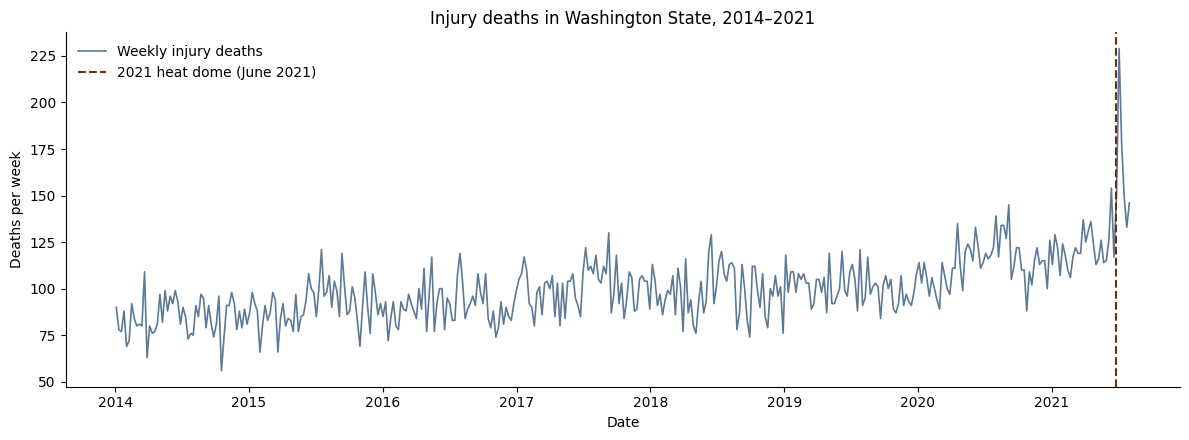

In [19]:
# plot time series (styling aligned with case_study1_sim_data.ipynb)
HEAT_DOME = pd.Timestamp("2021-06-25")

fig, ax = plt.subplots(figsize=(12, 4.5))

ax.plot(df_final["ds"], df_final["y"], lw=1.2, color="#4a6b8a", alpha=0.9,
        label="Weekly injury deaths")

ax.axvline(HEAT_DOME, color="#712b13", linestyle="--", lw=1.5,
           label=f"2021 heat dome (June 2021)")

ax.set_title("Injury deaths in Washington State, 2014\u20132021", fontsize=12)
ax.set_xlabel("Date")
ax.set_ylabel("Deaths per week")
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.legend(loc="upper left", frameon=False)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

fig.tight_layout()
plt.show()